In [ ]:
! pip install langgraph==1.2.2 langchain==1.3.2 langchain-groq==1.1.3 langchain-ollama==1.1.0 langchain-google-genai==4.2.4 google-genai langchain-mistralai==1.1.6 langchain-community==0.4.2 langchain-tavily==0.2.18 psycopg[binary]==3.3.4 psycopg_pool==3.3.1 python-dotenv==1.2.2 tavily-python==0.7.24 requests==2.34.2 langgraph-checkpoint-postgres==3.1.0 python-dotenv


In [218]:
import warnings
warnings.filterwarnings('ignore')

In [219]:
from dotenv import load_dotenv
load_dotenv(dotenv_path='/content/.env')

True

In [220]:
import os
import operator
from pydantic import BaseModel, Field
from typing import TypedDict, List, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langchain_mistralai import ChatMistralAI
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage

import psycopg
from psycopg.rows import dict_row
from langgraph.checkpoint.postgres import PostgresSaver

In [221]:
# Function to get DB URL

def get_database_url():
  '''
  Function to get database URL
  '''
  database_url = os.getenv('PG_DATABASE_URL')
  if not database_url:
      raise ValueError(
            "DATABASE_URL is missing. Please add your Render PostgreSQL External Database URL to .env"
      )

  if "sslmode=" not in database_url:
      separator = "&" if "?" in database_url else "?"
      database_url = f"{database_url}{separator}sslmode=require"

  return database_url

In [222]:
MISTRAL_API_KEY = os.getenv("MISTRAL_API_KEY")
if not MISTRAL_API_KEY:
    raise ValueError("MISTRAL_API_KEY is missing. Please add it to your .env file.")

In [223]:
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
if not GROQ_API_KEY:
    raise ValueError("GROQ_API_KEY is missing. Please add it to your .env file.")

In [224]:
class Task(BaseModel):
  id: int
  title: str
  brief: str = Field(..., description="What to cover")

In [225]:
class Plan(BaseModel):
  blog_title: str
  tasks: List[Task]

In [226]:
class State(TypedDict):
  topic: str
  plan: Plan
  # reducer: results from workers get concatenated automatically
  sections: Annotated[List[str], operator.add]
  final:str

In [227]:
llm = ChatGroq(
    model="whisper-large-v3-turbo",
    temperature=0.7,
    api_key=GROQ_API_KEY
)

In [228]:
llm2 = ChatMistralAI(
    model="mistral-small-2506",
    temperature=0.8,
    api_key=MISTRAL_API_KEY
)

In [229]:
def orchestrator(state: State) -> dict:
  '''
  Orchestrator function
  '''
  plan = llm2.with_structured_output(Plan).invoke(
      [
          SystemMessage(
              content=(
                    "Create a blog plan with 5-7 sections on the following topic."
                )
          ),
          HumanMessage(content=(f"Topic: {state["topic"]}")),
      ]
  )
  return {"plan": plan}

In [230]:
def fanout(state: State):
  return [
      Send("worker", {
          "task": task,
          "topic": state["topic"],
          "plan": state["plan"]
      })
      for task in state["plan"].tasks
  ]

In [231]:
def worker(payload: dict) -> dict:
  '''
  Worker function
  '''
  task = payload["task"]
  topic = payload["topic"]
  plan = payload["plan"]

  blog_title = plan.blog_title

  # Get the raw AI message response
  ai_response_message = llm2.invoke(
      [
          SystemMessage(
              content="Write one clean Markdown section."
          ),
          HumanMessage(
              content=(
                  f"Blog: {blog_title}\n"
                  f"Topic: {topic}\n\n"
                  f"Section: {task.title}\n"
                  f"Brief: {task.brief}\n\n"
                  "Return only the section content in Markdown."
              )
          )
      ]
  )
  # Extract the string content from the AI message
  section_content_string = ai_response_message.content.strip()

  return {"sections": [section_content_string]}

In [232]:
from pathlib import Path

def reducer(state: State) -> dict:
  '''
  Reducer function
  '''
  title = state['plan'].blog_title

  # Ensure all items in sections are strings before joining
  processed_sections = []
  for item in state["sections"]:
      if isinstance(item, str):
          processed_sections.append(item)
      elif hasattr(item, 'content'): # Assumes it's an AIMessage or similar
          processed_sections.append(str(item.content).strip())
      else:
          # Fallback for unexpected types, converting to string
          processed_sections.append(str(item))

  body = "\n\n".join(processed_sections).strip()

  final_md = f"# {title}\n\n{body}\n"

  # Now save the files

  filename = title.lower().replace(" ", "_") + ".md"
  output_path = Path(filename)
  output_path.write_text(final_md, encoding="utf-8")

  return {"final": final_md}

In [233]:
graph = StateGraph(State)

# Add nodes
graph.add_node("orchestrator", orchestrator)
graph.add_node("worker", worker)
graph.add_node("reducer", reducer)

# Add edges
graph.add_edge(START, "orchestrator")
graph.add_conditional_edges("orchestrator", fanout, ["worker"])
graph.add_edge("worker", "reducer")
graph.add_edge("reducer", END)

In [234]:
# =========================
# PostgreSQL Checkpointer
# =========================
DATABASE_URL = get_database_url()

_conn = psycopg.connect(
    DATABASE_URL,
    autocommit=True,
    row_factory=dict_row
)

checkpointer = PostgresSaver(_conn)
checkpointer.setup()

In [235]:
app = graph.compile(checkpointer=checkpointer)

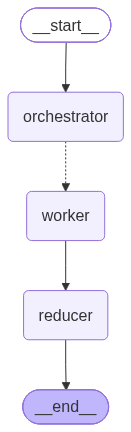

In [236]:
app

In [237]:
# Test Section

config = {
        "configurable": {
            "thread_id": "test_thread_id"
        }
    }

output = app.invoke({"topic": "Write a blog on Vector Database", "sections": []}, config=config)

In [238]:
output

{'topic': 'Write a blog on Vector Database',
 'plan': Plan(blog_title='Understanding Vector Databases: A Comprehensive Guide', tasks=[Task(id=1, title='Introduction to Vector Databases', brief='Define what a vector database is and its importance in modern data management. Explain the concept of vectors in data representation and how they differ from traditional databases.'), Task(id=2, title='Why Use Vector Databases?', brief='Discuss the use cases and advantages of vector databases, such as handling unstructured data, improving search accuracy, and enabling AI/ML applications. Provide examples like recommendation systems, image recognition, and natural language processing.'), Task(id=3, title='How Vector Databases Work', brief='Explain the technical aspects of vector databases, including how vectors are stored, indexed, and retrieved. Cover concepts like similarity search, approximate nearest neighbor (ANN) algorithms, and vector embeddings.'), Task(id=4, title='Key Features of Vector